# 1. Análise Exploratória dos Dados

Este notebook tem como objetivo compreender os principais padrões presentes no dataset **California Housing** e identificar fatores associados ao valor dos imóveis.

A análise contempla:

- comportamento da variável alvo;
- padrões geográficos de valorização;
- influência da proximidade do oceano;
- distribuição das variáveis numéricas e categóricas;
- relação entre renda média e valor dos imóveis;
- análise de correlação;
- criação e avaliação inicial de novas features.

Os resultados desta etapa serão utilizados para orientar as decisões de pré-processamento, Feature Engineering e modelagem realizadas posteriormente.

# 2. Importação das Bibliotecas

Nesta etapa são importadas as principais bibliotecas utilizadas para manipulação e visualização dos dados.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


# 3. Leitura e Verificação dos Dados

A base preparada anteriormente é carregada para iniciar a análise exploratória.

Nesta etapa são verificadas a dimensão do dataset, os tipos das variáveis e a presença de valores ausentes, garantindo que a estrutura dos dados permaneça consistente antes das análises estatísticas e visuais.

In [2]:
dados = pd.read_csv("../data/dados_housing.csv")
dados.head()

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,valor_media_imovel,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,proximo_baia
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,proximo_baia
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,proximo_baia
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,proximo_baia
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,proximo_baia


In [3]:
print(f"Total Linhas -> {dados.shape[0]}")
print(f"Total Colunas -> {dados.shape[1]}\n")
print(dados.info())

Total Linhas -> 20640
Total Colunas -> 10

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longitude              20640 non-null  float64
 1   latitude               20640 non-null  float64
 2   idade_mediana_imoveis  20640 non-null  float64
 3   total_comodos          20640 non-null  float64
 4   total_quartos          20433 non-null  float64
 5   populacao              20640 non-null  float64
 6   domicilios             20640 non-null  float64
 7   renda_media            20640 non-null  float64
 8   valor_media_imovel     20640 non-null  float64
 9   proximidade_oceano     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [4]:
print("Verificando Dados Nulos")
print(dados.isna().sum())

Verificando Dados Nulos
longitude                  0
latitude                   0
idade_mediana_imoveis      0
total_comodos              0
total_quartos            207
populacao                  0
domicilios                 0
renda_media                0
valor_media_imovel         0
proximidade_oceano         0
dtype: int64


# 4. Análise da Variável Alvo — Valor do Imóvel

A variável `valor_media_imovel` representa o valor que será previsto pelo modelo. Nesta etapa são analisadas suas estatísticas descritivas, distribuição e presença de valores extremos.

In [5]:
# Pegando os dados estatísticos dos preços
dados['valor_media_imovel'].describe().round(2)

count     20640.00
mean     206855.82
std      115395.62
min       14999.00
25%      119600.00
50%      179700.00
75%      264725.00
max      500001.00
Name: valor_media_imovel, dtype: float64

### Distribuição do Valor dos Imóveis

A distribuição apresenta **assimetria à direita**, com maior concentração de regiões nas faixas intermediárias de valor e redução gradual da frequência conforme os preços aumentam.

Também é possível observar uma concentração expressiva próxima de **US$ 500 mil**, indicando um possível limite superior de registro no dataset. Esse comportamento deverá ser considerado posteriormente na interpretação das previsões do modelo.

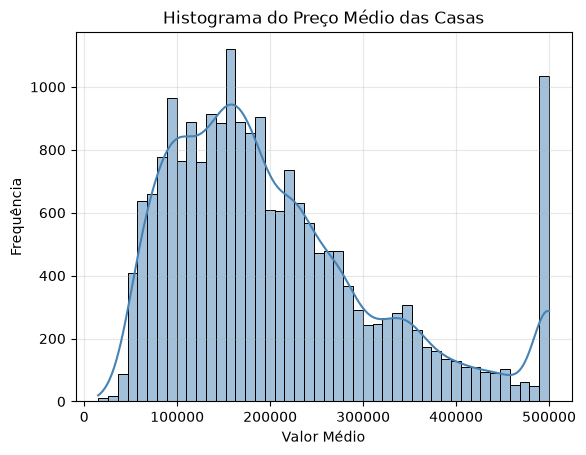

In [6]:
sns.histplot(data=dados, x='valor_media_imovel', kde=True, color='steelblue')
plt.title('Histograma do Preço Médio das Casas')
plt.xlabel('Valor Médio')
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

### Valores Extremos

O boxplot evidencia observações concentradas na faixa superior da distribuição. Esses valores não serão removidos automaticamente, pois podem representar regiões legitimamente mais valorizadas.

A decisão é preservar essas observações e avaliar seu impacto durante a modelagem e análise dos resíduos.

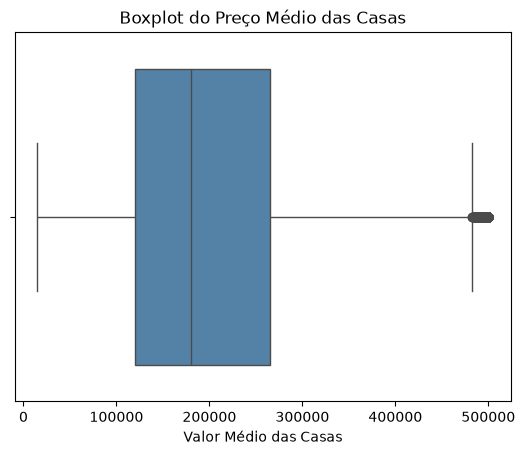

In [7]:
sns.boxplot(data=dados, x='valor_media_imovel', color='steelblue')
plt.title("Boxplot do Preço Médio das Casas")
plt.xlabel("Valor Médio das Casas")
plt.show()

# 5. Análise Geográfica dos Valores dos Imóveis

A localização exerce forte influência sobre o mercado imobiliário. Nesta etapa, são analisadas as coordenadas geográficas e a proximidade do oceano para identificar padrões espaciais de valorização e compreender sua relação com o valor dos imóveis.

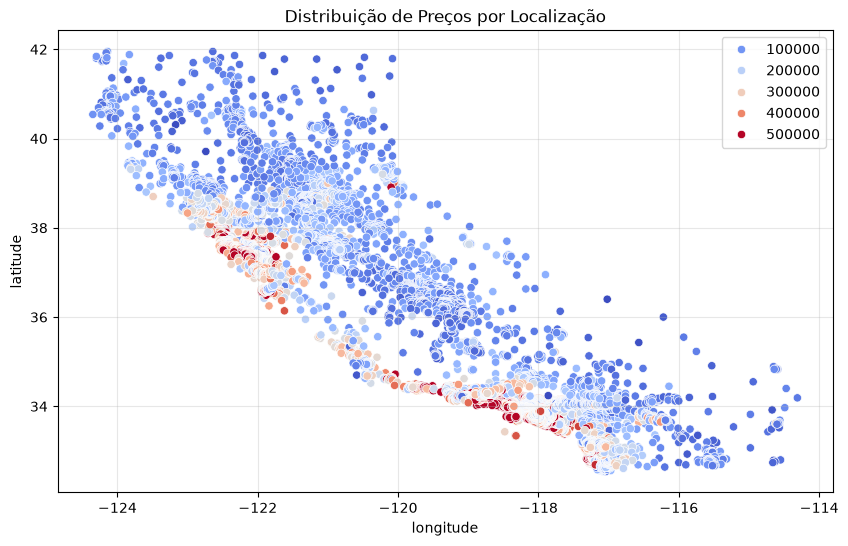

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=dados, x='longitude', y='latitude', hue='valor_media_imovel', palette='coolwarm')
plt.title('Distribuição de Preços por Localização')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


O gráfico evidencia um padrão geográfico de valorização. Regiões próximas à costa concentram grande parte dos maiores valores, enquanto áreas mais afastadas apresentam predominantemente preços menores.

Esse comportamento reforça a importância de `longitude` e `latitude` como variáveis relevantes para a modelagem.

## 5.1 Valores por Proximidade do Oceano

A análise agrupada confirma diferenças relevantes entre os perfis geográficos. Regiões do `interior` apresentam valor médio significativamente inferior, enquanto regiões próximas à baía e ao oceano possuem médias mais elevadas.

A categoria `ilha` apresenta o maior valor médio, porém possui apenas 5 registros, portanto esse resultado deve ser interpretado com cautela.

In [9]:
preco_oceano = (
    dados.groupby("proximidade_oceano")["valor_media_imovel"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .sort_values("media", ascending=False)
).round(2)

preco_oceano

,quantidade,media,mediana,desvio_padrao,minimo,maximo
proximidade_oceano,,,,,,
ilha,5,380440.00,414700.0,80559.56,287500.0,450000.0
proximo_baia,2290,259212.31,233800.0,122818.54,22500.0,500001.0
proximo_oceano,2658,249433.98,229450.0,122477.15,22500.0,500001.0
menos_1h_oceano,9136,240084.29,214850.0,106124.29,17500.0,500001.0
interior,6551,124805.39,108500.0,70007.91,14999.0,500001.0


## 5.2 Distribuição dos Valores por Perfil Geográfico

O boxplot reforça as diferenças entre as categorias de `proximidade_oceano`, principalmente entre regiões do interior e regiões costeiras.

Além das diferenças de mediana, regiões próximas ao litoral apresentam maior dispersão dos valores, indicando uma amplitude maior de preços nesses mercados.

De forma geral, a análise mostra que a localização geográfica possui forte relação com o valor dos imóveis.

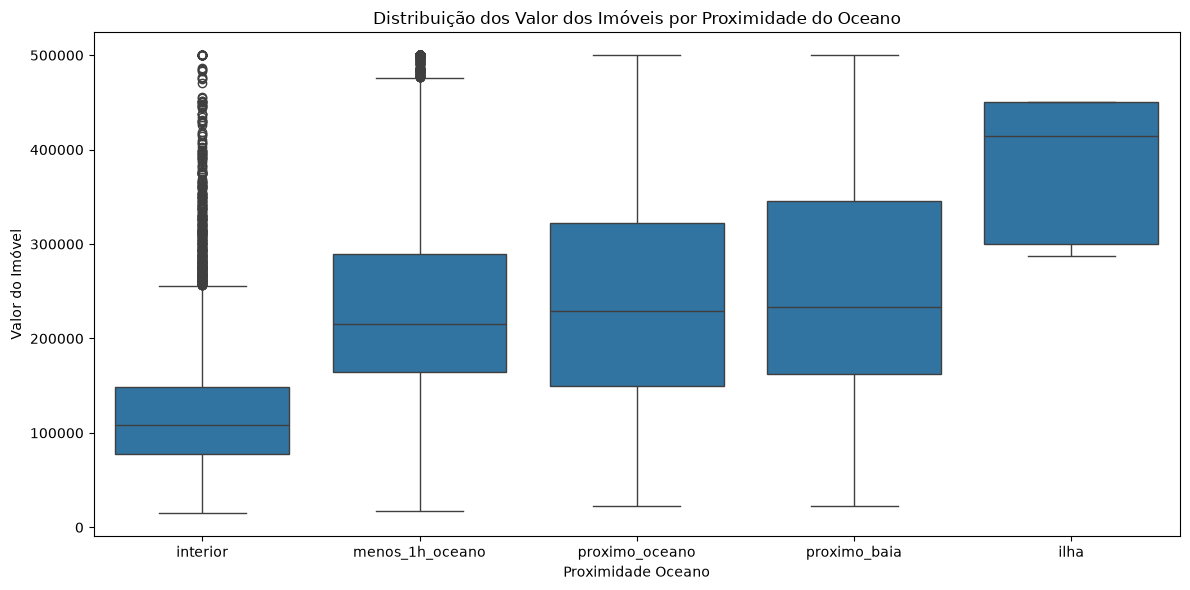

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(data=dados, x='proximidade_oceano', y='valor_media_imovel',
            order=["interior", "menos_1h_oceano", "proximo_oceano", "proximo_baia", "ilha"])
plt.title("Distribuição dos Valor dos Imóveis por Proximidade do Oceano")
plt.xlabel("Proximidade Oceano")
plt.ylabel("Valor do Imóvel")
plt.tight_layout()
plt.show()

# 6. Segmentação dos Imóveis por Faixa de Preço

Para facilitar a interpretação da variável alvo, os valores dos imóveis foram agrupados em quatro faixas: **Baixo, Médio, Alto e Luxo**.

Essa classificação possui finalidade exclusivamente exploratória, permitindo comparar diferentes níveis de preço e compreender melhor a composição do mercado presente no dataset.

In [11]:
dados['classe'] = pd.cut(dados['valor_media_imovel'],
                         bins=[0., 120000., 250000., 400000., np.inf],
                         labels=["Baixo", "Médio", "Alto", "Luxo"])
dados.head()

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_media,valor_media_imovel,proximidade_oceano,classe
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,proximo_baia,Luxo
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,proximo_baia,Alto
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,proximo_baia,Alto
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,proximo_baia,Alto
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,proximo_baia,Alto



A maior concentração de observações está na categoria **Médio**, seguida pelas categorias **Baixo** e **Alto**. Já a faixa **Luxo** representa uma parcela menor do conjunto de dados.

Essa distribuição mostra que o dataset possui maior representação de regiões com valores intermediários, enquanto regiões de maior valorização aparecem com menor frequência.

In [12]:
# Verificando a sua distribuição das classes
dados['classe'].value_counts().sort_values(ascending=False)

classe
Médio    9668
Baixo    5190
Alto     4038
Luxo     1744
Name: count, dtype: int64

## 6.1 Comparação entre os Segmentos

O valor médio cresce de forma consistente entre as quatro categorias, evidenciando uma separação clara entre os diferentes níveis de mercado.

A linha de referência representa o valor médio geral da base, próximo de **US$ 207 mil**. As categorias `Baixo` e `Médio` permanecem abaixo dessa referência, enquanto `Alto` e `Luxo` concentram regiões com valores superiores à média do dataset.

> A variável `classe` foi criada a partir da própria variável alvo e será utilizada apenas para fins exploratórios, não sendo utilizada como feature durante a modelagem para evitar **data leakage**.

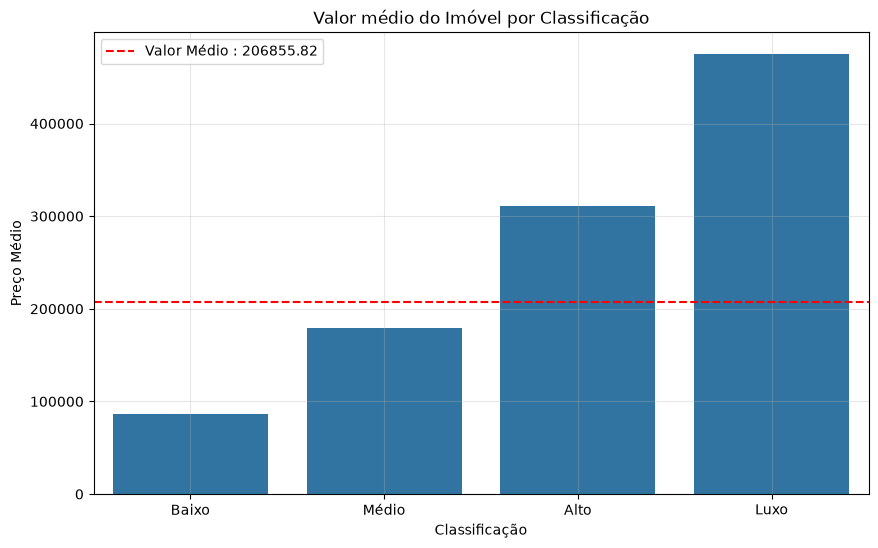

In [13]:
valor_medio = dados.groupby('classe')['valor_media_imovel'].mean()
valor_medio_dados = dados['valor_media_imovel'].mean().round(2)

plt.figure(figsize=(10, 6))
sns.barplot(x=valor_medio.index, y=valor_medio.values)
plt.axhline(valor_medio_dados, color="red", linestyle="--", label=f"Valor Médio : {valor_medio_dados}")
plt.title("Valor médio do Imóvel por Classificação")
plt.xlabel("Classificação")
plt.ylabel("Preço Médio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 7. Análise das Variáveis Numéricas

Nesta etapa são avaliadas as distribuições das variáveis numéricas e suas relações com o valor dos imóveis.

O objetivo é identificar assimetrias, valores extremos, possíveis relações com a variável alvo e características que possam exigir atenção durante a modelagem.

In [14]:
var_numericas = ['longitude','latitude','idade_mediana_imoveis','total_comodos','total_quartos','populacao','domicilios','renda_media']

## 7.1 Distribuição das Variáveis Numéricas

As variáveis apresentam comportamentos bastante distintos. `total_comodos`, `total_quartos`, `populacao` e `domicilios` possuem forte assimetria à direita, com grande concentração de observações em valores menores e uma pequena quantidade de regiões com valores muito elevados.

A `renda_media` também apresenta assimetria positiva, enquanto `longitude` e `latitude` refletem a própria distribuição espacial das regiões da Califórnia.

Esses padrões indicam a presença de escalas e distribuições diferentes entre as variáveis, aspecto que será considerado durante o pré-processamento.

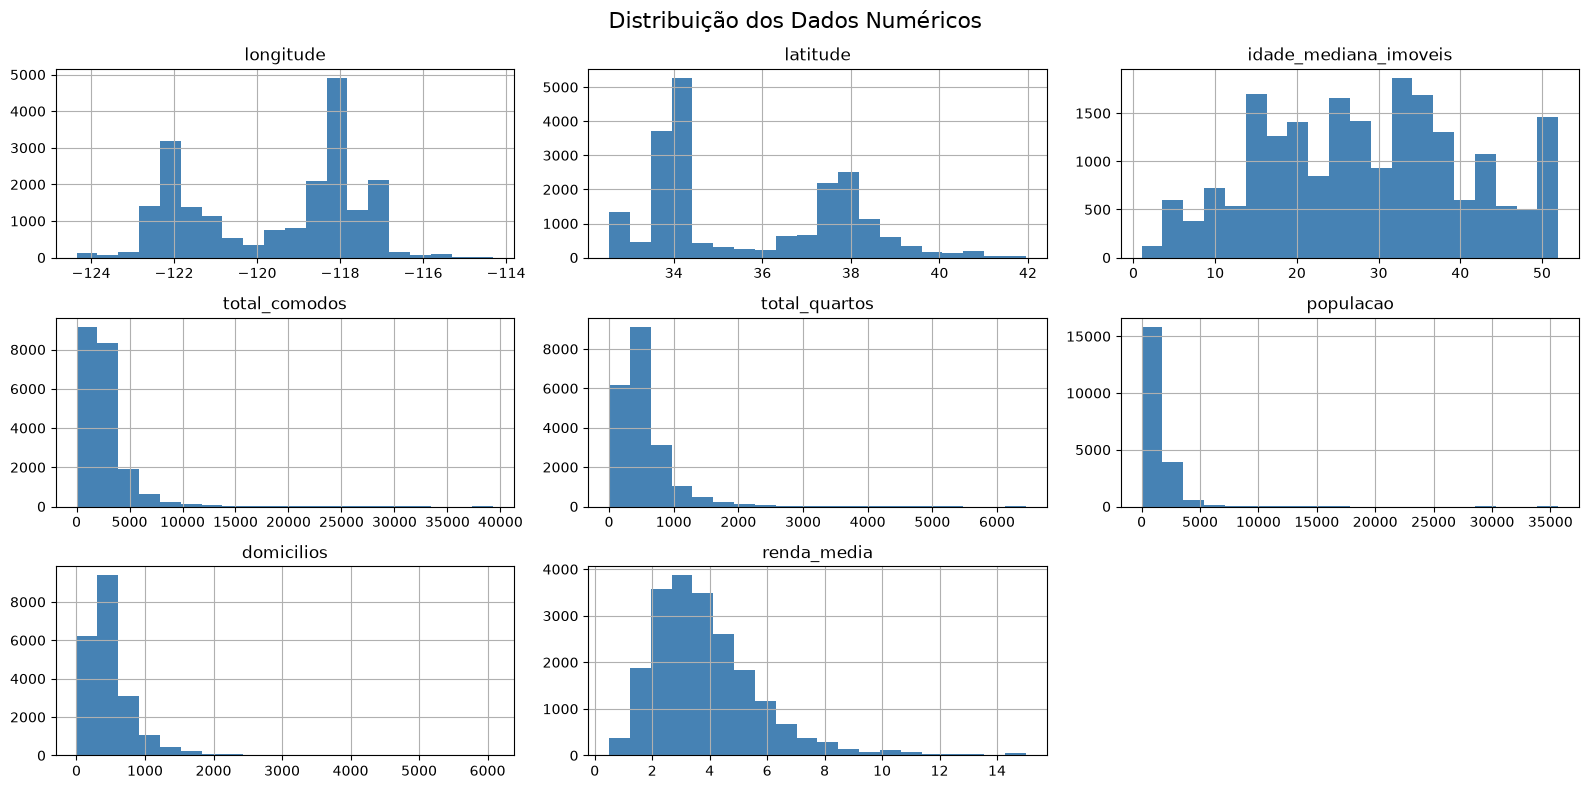

In [15]:
dados[var_numericas].hist(figsize=(16, 8), bins=20, color="steelblue")
plt.suptitle("Distribuição dos Dados Numéricos", fontsize=16)
plt.tight_layout()
plt.show()

## 7.2 Renda Média e Faixa de Valor dos Imóveis

A `renda_media` apresenta uma separação bastante clara entre as diferentes faixas de preço dos imóveis.

À medida que a renda média aumenta, observa-se um deslocamento consistente das regiões das classes `Baixo` e `Médio` para `Alto` e `Luxo`. Tanto o boxplot quanto as distribuições de densidade evidenciam essa relação.

Esse comportamento sugere que a renda média possui forte poder explicativo sobre o valor dos imóveis e provavelmente será uma das variáveis mais relevantes para o modelo.

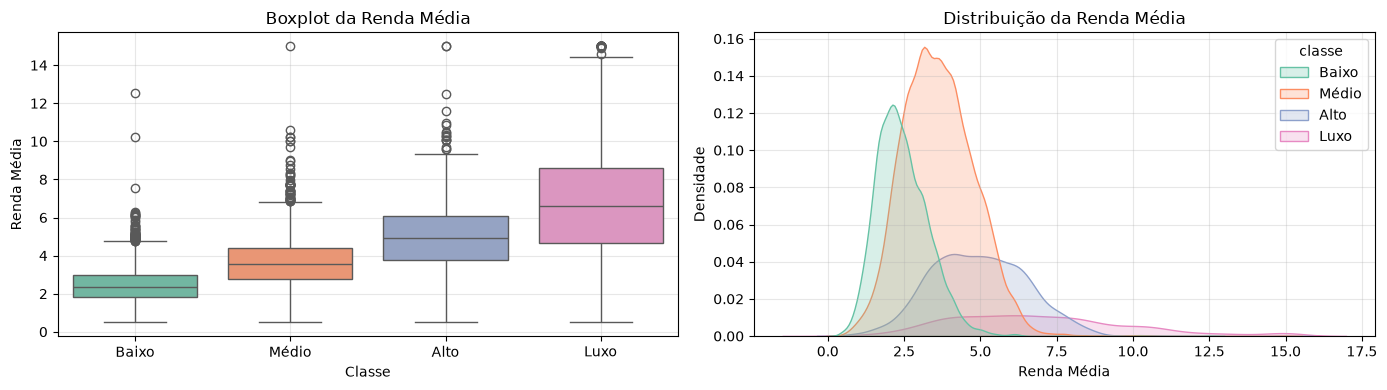

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
palette = "Set2"

# Boxplot
sns.boxplot(data=dados, x='classe', y='renda_media', ax=ax[0], palette=palette, hue='classe', legend=False, dodge=False)
ax[0].set_title("Boxplot da Renda Média")
ax[0].set_xlabel("Classe")
ax[0].set_ylabel("Renda Média")
ax[0].grid(alpha=0.3)

# Kdeplot
sns.kdeplot(data=dados, x='renda_media', hue='classe', fill=True, ax=ax[1], palette=palette)
ax[1].set_title("Distribuição da Renda Média")
ax[1].set_xlabel("Renda Média")
ax[1].set_ylabel("Densidade")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
var_correlacao = ['longitude','latitude','idade_mediana_imoveis','total_comodos','total_quartos','populacao','domicilios',
                  'renda_media','valor_media_imovel']

## 7.3 Correlação entre as Variáveis

Foi utilizada a correlação de **Spearman**, adequada para avaliar relações monotônicas sem exigir que as variáveis apresentem distribuição normal ou relação estritamente linear.

A matriz evidencia correlações muito elevadas entre `total_comodos`, `total_quartos`, `populacao` e `domicilios`. Isso ocorre porque essas variáveis representam diferentes dimensões do tamanho e da ocupação das regiões, carregando parcialmente informações semelhantes.

Esse comportamento indica presença de redundância entre algumas variáveis e motiva a criação posterior de atributos relativos, como quantidade de cômodos por domicílio e proporção de quartos por cômodo.

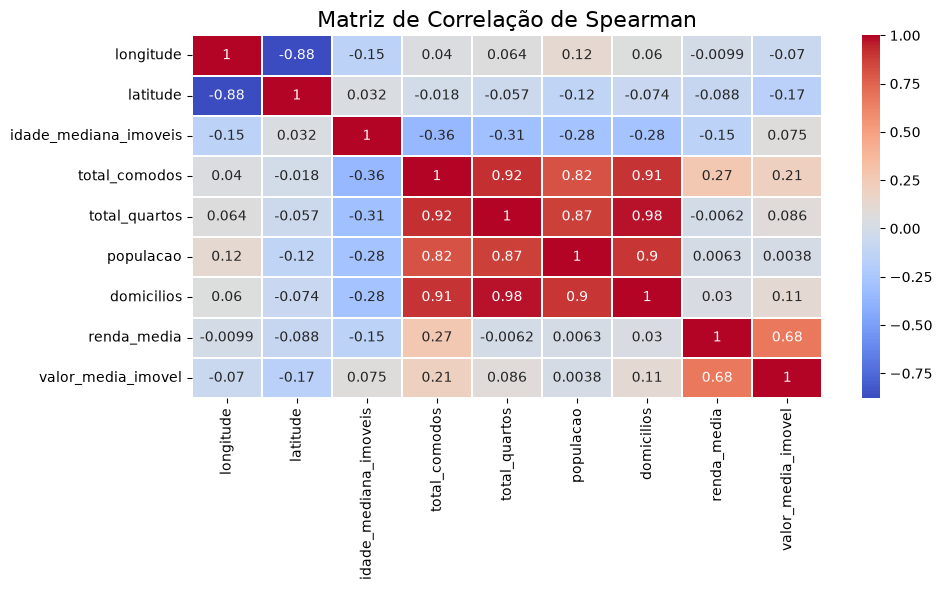

In [18]:
matriz_corr = (dados[var_correlacao].corr(method="spearman"))

plt.figure(figsize=(10,6))

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', linewidths=0.3)
plt.title("Matriz de Correlação de Spearman", fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
corr_target = (matriz_corr["valor_media_imovel"].drop("valor_media_imovel").sort_values(key=abs, ascending=False))
corr_target

renda_media              0.676778
total_comodos            0.205952
latitude                -0.165739
domicilios               0.112737
total_quartos            0.086259
idade_mediana_imoveis    0.074855
longitude               -0.069667
populacao                0.003839
Name: valor_media_imovel, dtype: float64

## 7.4 Relação das Variáveis com o Valor do Imóvel

Entre as variáveis numéricas, `renda_media` apresenta a relação mais forte com o valor dos imóveis, com correlação de Spearman próxima de **0,68**.

`total_comodos` apresenta uma associação positiva mais moderada, enquanto `latitude` possui uma relação negativa, refletindo parcialmente o efeito geográfico observado anteriormente.

Variáveis como `populacao`, `longitude` e `idade_mediana_imoveis` apresentam correlações individuais relativamente baixas. Isso, porém, não significa que sejam irrelevantes para modelos de Machine Learning, pois algoritmos não lineares podem explorar interações e padrões que uma correlação isolada não consegue capturar.

> Correlação representa associação e não implica relação causal.

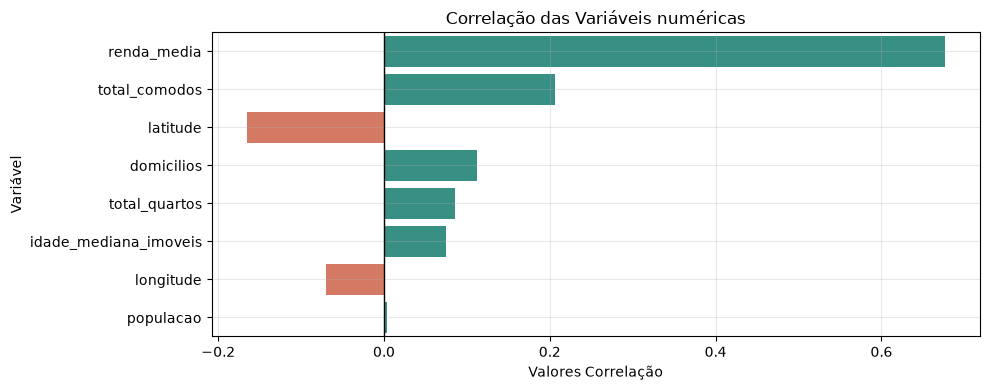

In [20]:
plt.figure(figsize=(10,4))

cores = ["#2a9d8f" if valor >= 0 else "#e76f51"
         for valor in corr_target.values]

sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette=cores, legend=False)
plt.axvline(0, color='black', linewidth=1)
plt.title("Correlação das Variáveis numéricas")
plt.xlabel("Valores Correlação")
plt.ylabel("Variável")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

## 7.5 Relação entre Renda Média e Valor do Imóvel

Como a `renda_media` apresentou a maior correlação com a variável alvo, sua relação com o valor dos imóveis é analisada diretamente por meio de um gráfico de dispersão.

A linha de tendência ajuda a visualizar o comportamento geral entre as duas variáveis.

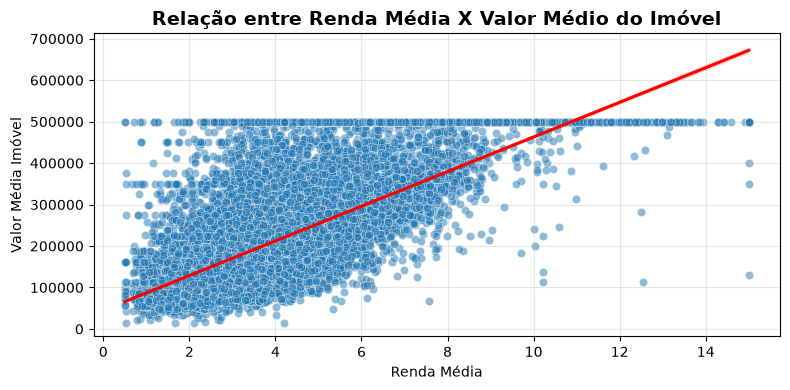

In [21]:
plt.figure(figsize=(8, 4))

sns.scatterplot(data=dados, x="renda_media", y="valor_media_imovel", alpha=0.5)
sns.regplot(data=dados, x="renda_media", y="valor_media_imovel", scatter=False, color="red")

plt.title("Relação entre Renda Média X Valor Médio do Imóvel", fontsize=14, fontweight="bold")
plt.xlabel("Renda Média")
plt.ylabel("Valor Média Imóvel")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretação

O gráfico evidencia uma relação positiva entre renda média e valor dos imóveis: regiões com maior renda tendem a apresentar valores imobiliários mais elevados.

Apesar dessa tendência, observa-se uma dispersão considerável dos pontos, indicando que a renda não explica sozinha o comportamento dos preços. Fatores geográficos e características das regiões também exercem influência relevante.

Também é novamente visível a concentração de observações próxima de **US$ 500 mil**, reforçando a existência de um limite superior na variável alvo.

# 8. Análise da Variável Categórica `proximidade_oceano`

A variável `proximidade_oceano` representa o perfil geográfico das regiões em relação ao litoral.

Nesta etapa são analisadas a frequência das categorias e sua relação com o valor dos imóveis, buscando compreender como diferentes localizações estão distribuídas na base e como se comportam em relação à variável alvo.

In [22]:
frequencia = (dados["proximidade_oceano"].value_counts().to_frame("quantidade"))

frequencia["percentual"] = (frequencia["quantidade"] / len(dados) *100).round(2)

print(frequencia)

                    quantidade  percentual
proximidade_oceano                        
menos_1h_oceano           9136       44.26
interior                  6551       31.74
proximo_oceano            2658       12.88
proximo_baia              2290       11.09
ilha                         5        0.02


## 8.1 Distribuição das Categorias

A maior parte das observações está concentrada nas categorias `menos_1h_oceano` e `interior`, que juntas representam aproximadamente **76% da base**.

As categorias `proximo_oceano` e `proximo_baia` possuem participação menor, enquanto `ilha` apresenta apenas **5 registros**, representando uma parcela praticamente residual do dataset.

Essa diferença de frequência deve ser considerada na interpretação das análises, principalmente para categorias com poucas observações.

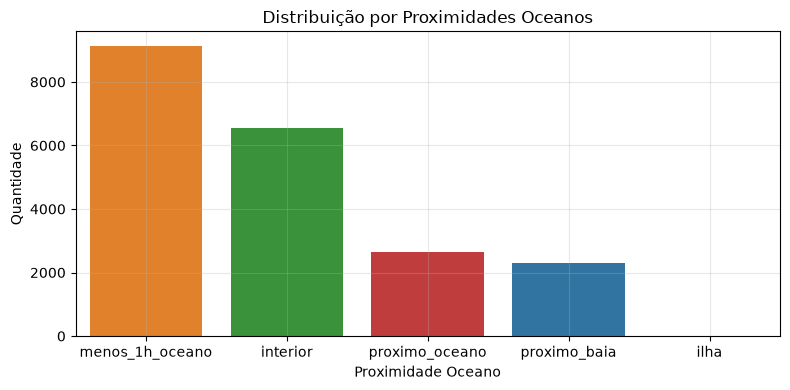

In [23]:
plt.figure(figsize=(8,4))

sns.countplot(data=dados, x="proximidade_oceano",order=dados["proximidade_oceano"].value_counts().index, hue="proximidade_oceano", legend=False)
plt.title("Distribuição por Proximidades Oceanos")
plt.xlabel("Proximidade Oceano")
plt.ylabel("Quantidade")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8.2 Relação com o Valor dos Imóveis

Os valores dos imóveis apresentam diferenças relevantes entre os perfis geográficos.

Regiões do `interior` possuem os menores valores médios e medianos, enquanto áreas próximas à baía e ao oceano apresentam valores significativamente mais elevados.

A categoria `ilha` possui a maior média da análise, porém seu resultado não deve ser generalizado devido à quantidade extremamente reduzida de observações.

In [24]:
analise_categoria = (
    dados.groupby("proximidade_oceano")["valor_media_imovel"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .sort_values(by="media", ascending=False).round(2)
)
analise_categoria

,quantidade,media,mediana,desvio_padrao,minimo,maximo
proximidade_oceano,,,,,,
ilha,5,380440.00,414700.0,80559.56,287500.0,450000.0
proximo_baia,2290,259212.31,233800.0,122818.54,22500.0,500001.0
proximo_oceano,2658,249433.98,229450.0,122477.15,22500.0,500001.0
menos_1h_oceano,9136,240084.29,214850.0,106124.29,17500.0,500001.0
interior,6551,124805.39,108500.0,70007.91,14999.0,500001.0


## 8.3 Distribuição dos Valores por Categoria

O boxplot reforça a diferença de valorização entre regiões costeiras e regiões do interior.

As categorias `proximo_baia`, `proximo_oceano` e `menos_1h_oceano` apresentam distribuições deslocadas para valores mais elevados, enquanto `interior` concentra os menores preços.

Também é possível observar maior dispersão nas regiões próximas ao litoral e diversos valores elevados no interior, indicando que a proximidade do oceano é relevante, mas não determina isoladamente o valor de uma região.

Esses resultados reforçam a importância de incluir `proximidade_oceano` como variável categórica durante a modelagem.

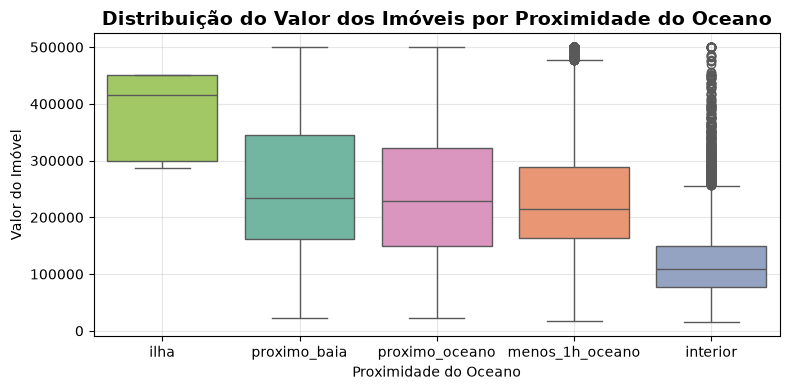

In [25]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=dados, x="proximidade_oceano", y="valor_media_imovel", hue="proximidade_oceano", order=["ilha", "proximo_baia", "proximo_oceano", "menos_1h_oceano", "interior"], palette="Set2", legend=False)

plt.title("Distribuição do Valor dos Imóveis por Proximidade do Oceano", fontsize=14, fontweight="bold")

plt.xlabel("Proximidade do Oceano")
plt.ylabel("Valor do Imóvel")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Feature Engineering

A partir das variáveis originais, foram criadas novas features com o objetivo de representar melhor algumas relações estruturais presentes nos dados.

Foram construídas:

- `comodos_por_domicilio`: quantidade média de cômodos por domicílio;
- `quartos_por_comodo`: proporção de quartos em relação ao total de cômodos.

Essas variáveis buscam transformar medidas absolutas em proporções potencialmente mais informativas para o modelo.

> A criação dessas features não garante melhoria de desempenho. Sua utilidade será avaliada posteriormente por meio de uma comparação entre modelos treinados com e sem Feature Engineering.

In [37]:
dados_fe = dados.copy()

dados_fe["comodos_por_domicilio"] = np.where(
    dados_fe["domicilios"] > 0,
    dados_fe["total_comodos"] / dados_fe["domicilios"],
    np.nan
)

dados_fe["quartos_por_comodo"] = np.where(
    dados_fe["total_comodos"] > 0,
    dados_fe["total_quartos"] / dados_fe["total_comodos"],
    np.nan
)


## 9.1 Relação das Novas Features com o Valor do Imóvel

As novas variáveis apresentam associação com a variável alvo.

`comodos_por_domicilio` possui correlação positiva de aproximadamente **0,26**, enquanto `quartos_por_comodo` apresenta correlação negativa próxima de **-0,33** com o valor dos imóveis.

Também existe uma correlação elevada entre as duas features, próxima de **-0,89**, indicando que elas carregam informações relacionadas entre si.

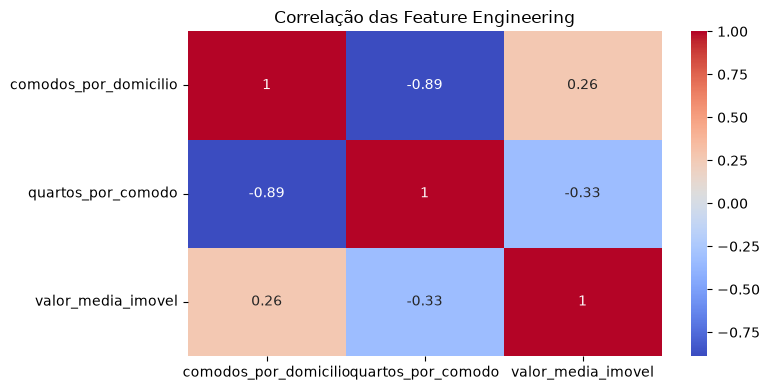

In [38]:
var_correlacao_fe = ['comodos_por_domicilio', 'quartos_por_comodo','valor_media_imovel']

fe_correlacao = dados_fe[var_correlacao_fe].corr(method="spearman")

plt.figure(figsize=(8, 4))

sns.heatmap(fe_correlacao, annot=True, cmap="coolwarm")
plt.title("Correlação das Feature Engineering")
plt.tight_layout()
plt.show()

## 9.2 Comportamento das Features Criadas

Os gráficos evidenciam tendências distintas entre as novas variáveis e o valor dos imóveis.

Regiões com maior quantidade de cômodos por domicílio tendem a apresentar valores mais elevados, enquanto uma maior proporção de quartos em relação ao total de cômodos está associada, em geral, a valores menores.

Também são observados valores extremos, principalmente em `comodos_por_domicilio`, o que indica que a relação não é estritamente linear e pode ser melhor explorada por modelos capazes de capturar comportamentos não lineares.

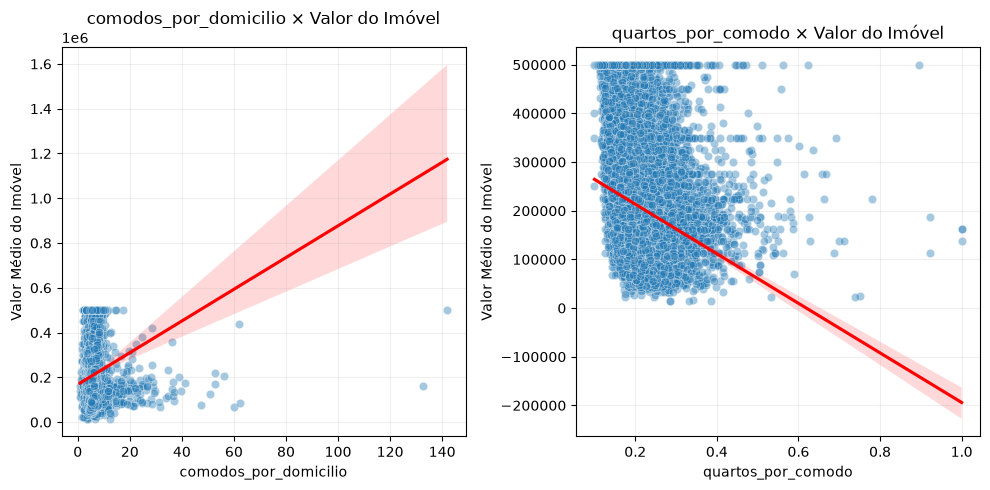

In [40]:
var_correlacao_fe = ["comodos_por_domicilio", "quartos_por_comodo"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for col, ax in zip(var_correlacao_fe, axes):

    sns.scatterplot(data=dados_fe, x=col, y="valor_media_imovel", alpha=0.4, ax=ax)

    sns.regplot(data=dados_fe, x=col, y="valor_media_imovel", scatter=False, color="red", ax=ax)

    ax.set_title(f"{col} × Valor do Imóvel")
    ax.set_xlabel(col)
    ax.set_ylabel("Valor Médio do Imóvel")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 9.3 Decisão para a Modelagem

As novas features serão mantidas como candidatas na etapa de modelagem, porém sua contribuição será avaliada empiricamente.

Será realizada uma comparação entre os mesmos modelos utilizando:

- apenas as variáveis originais;
- variáveis originais + Feature Engineering.

A decisão final de manter essas features será baseada no impacto observado nas métricas de validação, evitando assumir que novas variáveis necessariamente melhoram o desempenho do modelo.

# 10. Conclusão da Análise Exploratória

A análise exploratória revelou padrões importantes para a construção dos modelos de Machine Learning.

Entre os principais resultados, destacam-se:

- forte influência da localização sobre os valores imobiliários;
- regiões próximas ao litoral apresentam, em geral, valores superiores às regiões do interior;
- `renda_media` apresentou a associação numérica mais forte com a variável alvo;
- variáveis como `total_comodos`, `total_quartos`, `populacao` e `domicilios` apresentam elevada correlação entre si;
- a variável alvo possui assimetria e uma concentração próxima ao limite superior de US$ 500 mil;
- as features `comodos_por_domicilio` e `quartos_por_comodo` apresentaram relação com o valor dos imóveis e serão testadas durante a modelagem.

A próxima etapa consiste em construir e comparar diferentes modelos de regressão, avaliando também se as features criadas nesta análise contribuem efetivamente para melhorar o desempenho preditivo.